In [16]:
import pandas as pd
df = pd.read_csv('../data/UAVIDS-2025.csv')
print(df.head())

   FlowID  FlowDuration/s        SrcAddr  SrcPort       DstAddr  DstPort  \
0       1         175.007  192.168.0.150        9  192.168.0.16        9   
1       2         175.008  192.168.0.150        9  192.168.0.19        9   
2       3         175.010  192.168.0.150        9  192.168.0.24        9   
3       4         175.014  192.168.0.150        9  192.168.0.34        9   
4       5         175.017  192.168.0.150        9  192.168.0.39        9   

  Protocol  TxPackets  RxPackets  LostPackets  ...  RxPacketRate/s  \
0      UDP        251        215           36  ...         1.22853   
1      UDP        251        223           28  ...         1.27423   
2      UDP        251        224           27  ...         1.27993   
3      UDP        251        212           39  ...         1.21133   
4      UDP        251        215           36  ...         1.22845   

   TxByteRate/s  RxByteRate/s  MeanDelay/s  MeanJitter/s  Throughput/Kbps  \
0       109.002       93.3679     0.022152   

In [17]:
df = df.drop(['Protocol', 'FlowID'], axis = 1)

In [18]:
df = df.drop(['SrcAddr', 'DstAddr'], axis=1)

In [19]:
df.shape

(122171, 19)

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['label'])

df.head()

,FlowDuration/s,SrcPort,DstPort,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,TxPacketRate/s,RxPacketRate/s,TxByteRate/s,RxByteRate/s,MeanDelay/s,MeanJitter/s,Throughput/Kbps,MeanPacketSize,PacketDropRate,AverageHopCount,label
0,175.007,9,9,251,215,36,19076,16340,1.43423,1.22853,109.002,93.3679,0.022152,0.024406,0.746943,76,0.143426,0.074419,3
1,175.008,9,9,251,223,28,19076,16948,1.43422,1.27423,109.001,96.8411,0.019637,0.018678,0.774729,76,0.111554,0.053812,3
2,175.010,9,9,251,224,27,19076,17024,1.43420,1.27993,108.999,97.2744,0.023701,0.023917,0.778195,76,0.107570,0.044643,3
3,175.014,9,9,251,212,39,19076,16112,1.43417,1.21133,108.997,92.0614,0.034014,0.025408,0.736491,76,0.155378,0.033019,3
4,175.017,9,9,251,215,36,19076,16340,1.43415,1.22845,108.995,93.3623,0.034396,0.024933,0.746899,76,0.143426,0.009302,3


In [21]:
for i, attack in enumerate(label_encoder.classes_):
    print(i, "=", attack)

0 = Blackhole Attack
1 = Flooding Attack
2 = Normal Traffic
3 = Sybil Attack
4 = Wormhole Attack


In [22]:
X = df.drop('label', axis=1)
y = df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (122171, 18)
y shape: (122171,)


####
Top 10 features
####
top features = ["MeanPacketSize" , "TxByteRate/s" , "SrcPort" , "PacketDropRate" , "TxBytes" , "TxPackets" , "FlowDuration/s" , "TxPacketRate/s" , "RxBytes" , "LostPackets"]

In [23]:
top_features = ["MeanPacketSize" , "TxByteRate/s" , "SrcPort" , "PacketDropRate" , "TxBytes" , "TxPackets" , "FlowDuration/s" , "TxPacketRate/s" , "RxBytes" , "LostPackets"]

X_top = X[top_features]

print(X_top.head())

print(X_top.shape)

   MeanPacketSize  TxByteRate/s  SrcPort  PacketDropRate  TxBytes  TxPackets  \
0              76       109.002        9        0.143426    19076        251   
1              76       109.001        9        0.111554    19076        251   
2              76       108.999        9        0.107570    19076        251   
3              76       108.997        9        0.155378    19076        251   
4              76       108.995        9        0.143426    19076        251   

   FlowDuration/s  TxPacketRate/s  RxBytes  LostPackets  
0         175.007         1.43423    16340           36  
1         175.008         1.43422    16948           28  
2         175.010         1.43420    17024           27  
3         175.014         1.43417    16112           39  
4         175.017         1.43415    16340           36  
(122171, 10)


In [24]:
from sklearn.model_selection import train_test_split

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train_top.shape)
print("Testing :", X_test_top.shape)

Training: (97736, 10)
Testing : (24435, 10)


Standardization

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train_scaled = scaler.fit_transform(X_train_top)

In [28]:
X_test_scaled = scaler.transform(X_test_top)

In [29]:
print("Training:", X_train_scaled.shape)
print("Testing :", X_test_scaled.shape)

Training: (97736, 10)
Testing : (24435, 10)


In [30]:
import pandas as pd

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train_top.columns
)

print(X_train_scaled_df.describe().round(2))

       MeanPacketSize  TxByteRate/s   SrcPort  PacketDropRate   TxBytes  \
count        97736.00      97736.00  97736.00        97736.00  97736.00   
mean             0.00         -0.00      0.00           -0.00      0.00   
std              1.00          1.00      1.00            1.00      1.00   
min             -2.75         -0.02     -0.57           -1.19     -0.28   
25%              0.57         -0.02     -0.57           -0.90     -0.27   
50%              0.57         -0.02     -0.57           -0.27     -0.26   
75%              0.57         -0.01     -0.57            0.88     -0.13   
max              0.57        229.27      1.74            3.11     86.84   

       TxPackets  FlowDuration/s  TxPacketRate/s   RxBytes  LostPackets  
count   97736.00        97736.00        97736.00  97736.00     97736.00  
mean        0.00           -0.00           -0.00      0.00        -0.00  
std         1.00            1.00            1.00      1.00         1.00  
min        -0.24           -

SVM baseline model


In [31]:
from sklearn.svm import SVC

In [32]:
svm_model = SVC(random_state=42)

In [33]:
svm_model.fit(X_train_scaled, y_train_top)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [34]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_top, y_pred_svm)
print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.8590955596480458


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test_top, y_pred_svm))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83      5222
           1       0.77      0.86      0.81      3945
           2       0.98      0.94      0.96      5235
           3       0.91      0.82      0.86      4816
           4       0.73      0.94      0.82      5217

    accuracy                           0.86     24435
   macro avg       0.87      0.86      0.86     24435
weighted avg       0.88      0.86      0.86     24435



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_top, y_pred_svm)
print(cm)

[[3794    0    3    0 1425]
 [   0 3396    2  389  158]
 [  25  106 4937    0  167]
 [   0  819    9 3952   36]
 [ 146   85   73    0 4913]]


Decision tree baseline model

In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
dt_model = DecisionTreeClassifier(random_state=42)

In [40]:
dt_model.fit(X_train_scaled, y_train_top)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [41]:
y_pred_dt = dt_model.predict(X_test_scaled)

In [42]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test_top, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9406179660323307


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test_top, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      5222
           1       0.99      0.98      0.98      3945
           2       0.99      0.99      0.99      5235
           3       0.99      1.00      0.99      4816
           4       0.87      0.86      0.87      5217

    accuracy                           0.94     24435
   macro avg       0.94      0.94      0.94     24435
weighted avg       0.94      0.94      0.94     24435



In [44]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test_top, y_pred_dt)
print(cm_dt)

[[4636    3    1    1  581]
 [   0 3852    0   61   32]
 [   2    0 5190    0   43]
 [   0   16    0 4798    2]
 [ 620   21   60    8 4508]]


Random forest baseline model

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [47]:
rf_model.fit(X_train_scaled, y_train_top)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [48]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [49]:
rf_accuracy = accuracy_score(y_test_top, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9456517290771435


In [50]:
print(classification_report(y_test_top, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      5222
           1       0.99      0.99      0.99      3945
           2       0.99      0.99      0.99      5235
           3       0.99      1.00      1.00      4816
           4       0.87      0.88      0.88      5217

    accuracy                           0.95     24435
   macro avg       0.95      0.95      0.95     24435
weighted avg       0.95      0.95      0.95     24435



In [51]:
cm_rf = confusion_matrix(y_test_top, y_pred_rf)
print(cm_rf)

[[4614    3    1    0  604]
 [   0 3898    0   32   15]
 [   1    0 5193    0   41]
 [   0    1    0 4813    2]
 [ 547   18   61    2 4589]]


XG Boost baseline model


In [52]:
from xgboost import XGBClassifier

In [53]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

In [54]:
xgb_model.fit(X_train_scaled, y_train_top)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [55]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [56]:
xgb_accuracy = accuracy_score(y_test_top, y_pred_xgb)
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9497032944546757


In [57]:
print(classification_report(y_test_top, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90      5222
           1       0.98      0.98      0.98      3945
           2       0.99      0.99      0.99      5235
           3       0.98      0.99      0.99      4816
           4       0.86      0.94      0.90      5217

    accuracy                           0.95     24435
   macro avg       0.95      0.95      0.95     24435
weighted avg       0.95      0.95      0.95     24435



In [58]:
cm_xgb = confusion_matrix(y_test_top, y_pred_xgb)
print(cm_xgb)

[[4464    2    1    0  755]
 [   1 3852    0   73   19]
 [   0    0 5193    0   42]
 [   0   46    0 4768    2]
 [ 201   15   72    0 4929]]


comparison table for baseline model

In [59]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "SVM"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy,
        accuracy
    ]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.940618
1  Random Forest  0.945652
2        XGBoost  0.949703
3            SVM  0.859096


Cross Validation

In [60]:
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(
    dt_model,
    X_train_scaled,
    y_train_top,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree CV Scores:", dt_cv)
print("Mean:", dt_cv.mean())
print("Std:", dt_cv.std())

Decision Tree CV Scores: [0.93636178 0.93927457 0.93927457 0.93983732 0.93671663]
Mean: 0.9382929722026281
Std: 0.0014509601882725116


In [61]:
rf_cv = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train_top,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", rf_cv)
print("Mean:", rf_cv.mean())
print("Std:", rf_cv.std())

Random Forest CV Scores: [0.94168201 0.94541362 0.9435719  0.94393001 0.94213946]
Mean: 0.9433474018313449
Std: 0.001333546767168594


In [62]:
xgb_cv = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train_top,
    cv=5,
    scoring="accuracy"
)

print("XGBoost CV Scores:", xgb_cv)
print("Mean:", xgb_cv.mean())
print("Std:", xgb_cv.std())

XGBoost CV Scores: [0.94776959 0.95160383 0.94955748 0.94955748 0.94884125]
Mean: 0.949465925517033
Std: 0.001253406824323012


In [63]:
svm_cv = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train_top,
    cv=5,
    scoring="accuracy"
)

print("SVM CV Scores:", svm_cv)
print("Mean:", svm_cv.mean())
print("Std:", svm_cv.std())

SVM CV Scores: [0.8530796  0.85706246 0.85087226 0.85665319 0.85210007]
Mean: 0.8539535163493228
Std: 0.0024757622769175504


In [65]:
cv_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "SVM"
    ],
    "Mean CV Accuracy": [
        dt_cv.mean(),
        rf_cv.mean(),
        xgb_cv.mean(),
        svm_cv.mean()
    ],
    "Std Deviation": [
        dt_cv.std(),
        rf_cv.std(),
        xgb_cv.std(),
        svm_cv.std()
    ]
})

print(cv_results)

           Model  Mean CV Accuracy  Std Deviation
0  Decision Tree          0.938293       0.001451
1  Random Forest          0.943347       0.001334
2        XGBoost          0.949466       0.001253
3            SVM          0.853954       0.002476


both baseline and cv results

In [66]:
comparison_before_tuning = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost", "SVM"],
    "Baseline Accuracy": [dt_accuracy, rf_accuracy, xgb_accuracy, accuracy],
    "CV Mean Accuracy": [dt_cv.mean(), rf_cv.mean(), xgb_cv.mean(), svm_cv.mean()],
    "CV Std Dev": [dt_cv.std(), rf_cv.std(), xgb_cv.std(), svm_cv.std()]
})

print(comparison_before_tuning)

           Model  Baseline Accuracy  CV Mean Accuracy  CV Std Dev
0  Decision Tree           0.940618          0.938293    0.001451
1  Random Forest           0.945652          0.943347    0.001334
2        XGBoost           0.949703          0.949466    0.001253
3            SVM           0.859096          0.853954    0.002476


Parameter Grid

In [67]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [68]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [69]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6]
}

In [72]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

Grid Search

In [74]:
from sklearn.model_selection import GridSearchCV

In [75]:
grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [76]:
grid_dt.fit(X_train_scaled, y_train_top)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [77]:
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [78]:
grid_rf.fit(X_train_scaled, y_train_top)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ve

In [79]:
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [80]:
grid_xgb.fit(X_train_scaled, y_train_top)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 6], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

In [81]:
grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [82]:
grid_svm.fit(X_train_scaled, y_train_top)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

In [83]:
print("Best Parameters in case of decision tree:", grid_dt.best_params_)
print("Best CV Score in case of decision tree:", grid_dt.best_score_)
print("Best Parameters in case of random forest:", grid_rf.best_params_)
print("Best CV Score in case of random forest:", grid_rf.best_score_)
print("Best Parameters in case of XGBoost:", grid_xgb.best_params_)
print("Best CV Score in case of XGBoost:", grid_xgb.best_score_)
print("Best Parameters in case of SVM:", grid_svm.best_params_)
print("Best CV Score in case of SVM:", grid_svm.best_score_)

Best Parameters in case of decision tree: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score in case of decision tree: 0.941863806060556
Best Parameters in case of random forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score in case of random forest: 0.9499365859764384
Best Parameters in case of XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best CV Score in case of XGBoost: 0.9454346619019838
Best Parameters in case of SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV Score in case of SVM: 0.8804227822801556


Evaluation of tuned model on test set


In [84]:
best_dt = grid_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

dt_tuned_accuracy = accuracy_score(y_test_top, y_pred_dt_tuned)

print(dt_tuned_accuracy)

0.9433190096173522


In [85]:
best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_scaled)

rf_tuned_accuracy = accuracy_score(y_test_top, y_pred_rf_tuned)

print(rf_tuned_accuracy)

0.9522815633312871


In [86]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

xgb_tuned_accuracy = accuracy_score(y_test_top, y_pred_xgb_tuned)

print(xgb_tuned_accuracy)

0.946633926744424


In [87]:
best_svm = grid_svm.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test_scaled)

svm_tuned_accuracy = accuracy_score(y_test_top, y_pred_svm_tuned)

print(svm_tuned_accuracy)

0.8831184775936157


In [88]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "SVM"
    ],
    "Baseline Accuracy": [
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy,
        accuracy
    ],
    "Tuned Accuracy": [
        dt_tuned_accuracy,
        rf_tuned_accuracy,
        xgb_tuned_accuracy,
        svm_tuned_accuracy
    ]
})

final_results["Improvement"] = (
    final_results["Tuned Accuracy"] -
    final_results["Baseline Accuracy"]
)

print(final_results)

           Model  Baseline Accuracy  Tuned Accuracy  Improvement
0  Decision Tree           0.940618        0.943319     0.002701
1  Random Forest           0.945652        0.952282     0.006630
2        XGBoost           0.949703        0.946634    -0.003069
3            SVM           0.859096        0.883118     0.024023


In [89]:
final_models = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost", "SVM"],
    "Final Accuracy": [
        dt_tuned_accuracy,
        rf_tuned_accuracy,
        xgb_accuracy,          # Baseline kept
        svm_tuned_accuracy
    ],
    "Selected Version": [
        "Tuned",
        "Tuned",
        "Baseline",
        "Tuned"
    ]
})

print(final_models)

           Model  Final Accuracy Selected Version
0  Decision Tree        0.943319            Tuned
1  Random Forest        0.952282            Tuned
2        XGBoost        0.949703         Baseline
3            SVM        0.883118            Tuned


Feature importance

In [90]:
import pandas as pd

dt_importance = pd.DataFrame({
    "Feature": X_train_top.columns,
    "Importance": best_dt.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

print(dt_importance)

          Feature  Importance
1    TxByteRate/s    0.386043
3  PacketDropRate    0.226331
7  TxPacketRate/s    0.151882
6  FlowDuration/s    0.069954
0  MeanPacketSize    0.056031
2         SrcPort    0.050069
5       TxPackets    0.022867
9     LostPackets    0.014388
4         TxBytes    0.011940
8         RxBytes    0.010495


In [91]:
rf_importance = pd.DataFrame({
    "Feature": X_train_top.columns,
    "Importance": best_rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

          Feature  Importance
1    TxByteRate/s    0.209787
3  PacketDropRate    0.174523
7  TxPacketRate/s    0.169112
6  FlowDuration/s    0.121321
0  MeanPacketSize    0.058854
8         RxBytes    0.058540
4         TxBytes    0.057916
9     LostPackets    0.054541
2         SrcPort    0.051250
5       TxPackets    0.044157


In [92]:
xgb_importance = pd.DataFrame({
    "Feature": X_train_top.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance)

          Feature  Importance
0  MeanPacketSize    0.346539
1    TxByteRate/s    0.209003
3  PacketDropRate    0.131542
5       TxPackets    0.094265
4         TxBytes    0.071780
7  TxPacketRate/s    0.051728
6  FlowDuration/s    0.039675
9     LostPackets    0.035999
8         RxBytes    0.019469
2         SrcPort    0.000000


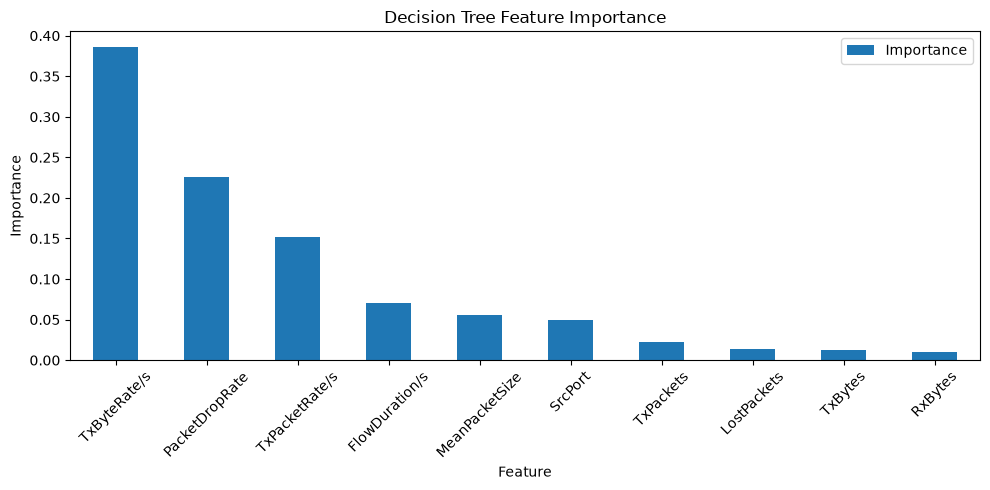

In [95]:
import matplotlib.pyplot as plt

dt_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

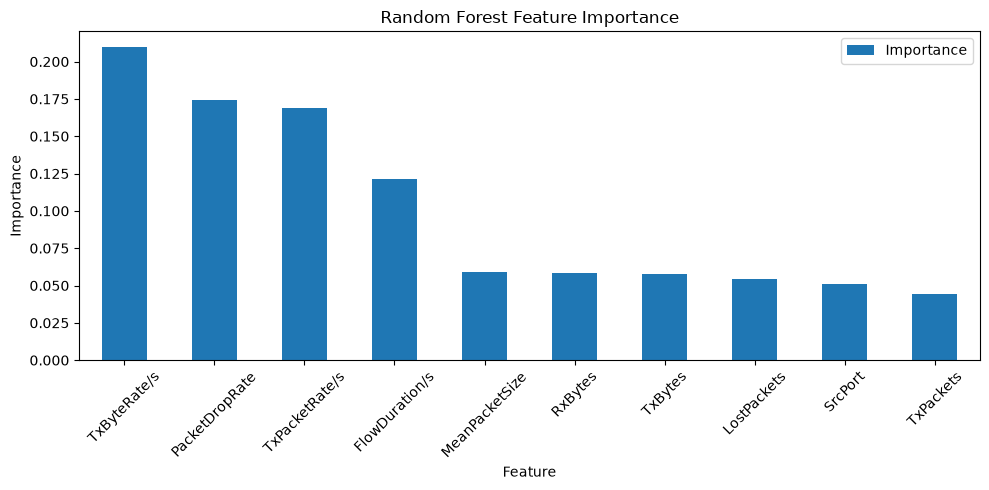

In [94]:
import matplotlib.pyplot as plt

rf_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

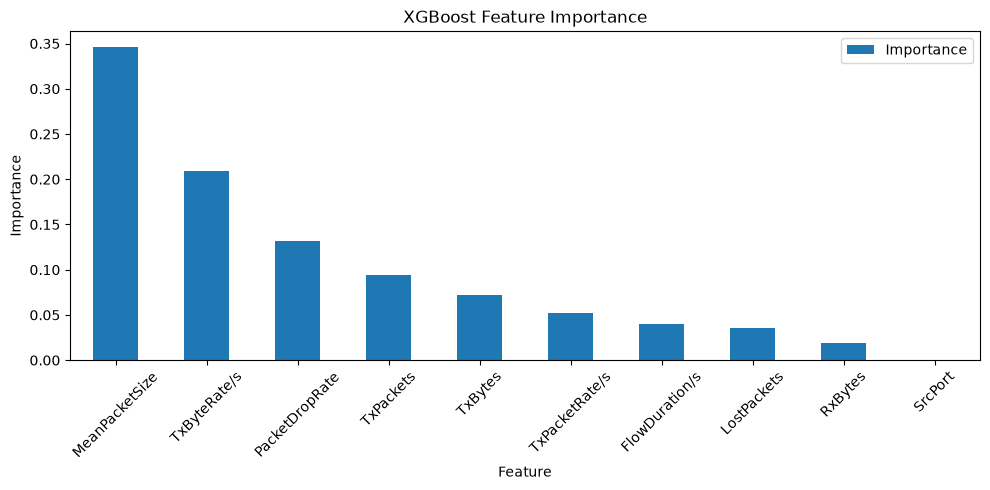

In [96]:
import matplotlib.pyplot as plt

xgb_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:
pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.8/41.9 MB 2.4 MB/s eta 0:00:18
   - -------------------------------------- 1.3/41.9 MB 2.4 MB/s eta 0:00:17
   -- ------------------------------------- 2.1/41.9 MB 2.6 MB/s eta 0:00:16
   -- ------------------------------------- 2.6/41.9 MB 2.6 MB/s eta 0:00:16
   --- ------------------------------------ 3.4/41.9 MB 2.7 MB/s eta 0:00:15
   --- ------------------------------------ 3.9/41.9 MB 2.7 MB/s eta 0:00:14
   ---- ----------------------------------- 4.5/41.9 MB 2.7 MB/s eta 0:00:14
   ----- ---------------------------------- 5.2/41.9 MB 2.8 MB/s eta 0:00:14
   ----- ---------------------------------- 5.5/41.9 MB 2.8 MB/s eta 0:00:14
   ------ --------------------------------- 6.3/41.9 MB 2.7 MB/s eta 0:00:13
   ------ --------------------------------- 6.8/41.9 MB 2.7 MB/s eta 0:00:13
   ------- --

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import shap

ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.